# Data Preprocessing and Cleaning

In [5]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("bug_severity_classification_dataset_v2.xlsx")

# Preview the dataset
print(df.head())
print(df.info())


   frequency  description_length asset_type  game_area  is_blocker  \
0          3                 100         UI       Menu           0   
1          1                 113        VFX     Level2           0   
2          6                 223        VFX  BossArena           1   
3         10                 135         UI  BossArena           0   
4          3                 207  Structure   Cutscene           1   

   is_graphical  steps_to_reproduce  reported_by_QA_level platform  \
0             1                   2                     1     Xbox   
1             1                   3                     0      PS5   
2             0                   6                     0      PS5   
3             1                   4                     1      PS5   
4             0                   4                     1     Xbox   

   has_screenshot  ...  is_regression  is_multiplayer_related  reported_build  \
0               0  ...              0                       1           v1.04

In [ ]:
print(df.isnull().sum()) #-->checking m,ising values


frequency                 0
description_length        0
asset_type                0
game_area                 0
is_blocker                0
is_graphical              0
steps_to_reproduce        0
reported_by_QA_level      0
platform                  0
has_screenshot            0
occurs_randomly           0
is_regression             0
is_multiplayer_related    0
reported_build            0
time_to_repro_sec         0
expected_fix_effort       0
similar_bugs_count        0
audio_affected            0
UI_affected               0
physics_related           0
severity                  0
dtype: int64


In [ ]:
print(df.dtypes) #----> checking numerical & categorical datatypes for bifurcation


frequency                  int64
description_length         int64
asset_type                object
game_area                 object
is_blocker                 int64
is_graphical               int64
steps_to_reproduce         int64
reported_by_QA_level       int64
platform                  object
has_screenshot             int64
occurs_randomly            int64
is_regression              int64
is_multiplayer_related     int64
reported_build            object
time_to_repro_sec          int64
expected_fix_effort        int64
similar_bugs_count         int64
audio_affected             int64
UI_affected                int64
physics_related            int64
severity                   int64
dtype: object


checking unique categories in each cat columns

In [8]:
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    print(f"{col}: {df[col].unique()}")


asset_type: ['UI' 'VFX' 'Structure' 'Character' 'Prop' 'Vegetation']
game_area: ['Menu' 'Level2' 'BossArena' 'Cutscene' 'Level1' 'Lobby']
platform: ['Xbox' 'PS5' 'PC']
reported_build: ['v1.04' 'v1.02' 'v1.01' 'v1.03']


## Train - Test Split

In [15]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop(columns='severity')
y = df['severity']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [16]:
X_train, X_test

(     frequency  description_length  asset_type  game_area  is_blocker  \
 170          8                  76        Prop     Level1           0   
 246          1                 247  Vegetation   Cutscene           1   
 212          8                 188  Vegetation   Cutscene           1   
 324          4                  30         VFX     Level2           1   
 306         10                  73         VFX      Lobby           1   
 ..         ...                 ...         ...        ...         ...   
 282          3                 144   Structure     Level2           1   
 124          7                 205          UI      Lobby           0   
 259          2                 125        Prop       Menu           1   
 326          5                 130        Prop  BossArena           1   
 72           8                 148  Vegetation       Menu           0   
 
      is_graphical  steps_to_reproduce  reported_by_QA_level platform  \
 170             1                   

## performed standard scalling on numerical values and did OHE for column transformation 

In [19]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Remove target from features
if 'severity' in numerical_features:
    numerical_features.remove('severity')

# Pipelines for each type
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine them
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])


## Used multiple models with parameters and instantiated these models via dictionaries for further training

In [20]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

models = {
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    "Logistic Regression": LogisticRegression(max_iter=1000, multi_class='multinomial', class_weight='balanced')
}


## Trained these models and created a pipeline to store these model accuracy

In [ ]:
from sklearn.metrics import classification_report

results = {}

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
   
    pipeline.fit(X_train, y_train)
    
    
    y_pred = pipeline.predict(X_test)
    
    print(f"\nModel: {name}")
    print(classification_report(y_test, y_pred))
    
    results[name] = pipeline  #---->stored in variables for later use.



Model: Random Forest
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        47
           1       1.00      0.92      0.96        12
           2       1.00      1.00      1.00        41

    accuracy                           0.99       100
   macro avg       0.99      0.97      0.98       100
weighted avg       0.99      0.99      0.99       100


Model: XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        41

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.91      0.95        47
           1       0.80      1.00      0.89        12
         

d:\ML assignment\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:49:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\ML assignment\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## created a pickle file to sore the values

In [22]:
import joblib

# Save Random Forest model, for example
joblib.dump(results["Random Forest"], "random_forest_bug_severity.pkl")


['random_forest_bug_severity.pkl']

## Performed RandomizedSearchCV for Each Model 

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


In [24]:
param_distributions = {
    "Random Forest": {
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': randint(5, 30),
        'classifier__min_samples_split': randint(2, 10),
        'classifier__min_samples_leaf': randint(1, 5)
    },
    "XGBoost": {
        'classifier__n_estimators': randint(50, 200),
        'classifier__max_depth': randint(3, 10),
        'classifier__learning_rate': uniform(0.01, 0.3),
        'classifier__subsample': uniform(0.6, 0.4)
    },
    "Logistic Regression": {
        'classifier__C': uniform(0.1, 10)
    }
}


In [25]:
from sklearn.metrics import classification_report

tuned_results = {}

for name, model in models.items():
    print(f"🔍 Tuning model: {name}")
    
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # RandomizedSearchCV
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_distributions[name],
        n_iter=20,
        cv=5,
        scoring='f1_macro',
        verbose=1,
        n_jobs=-1,
        random_state=42
    )
    
    # Fit
    search.fit(X_train, y_train)
    
    # Best model evaluation
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    print(f"\nBest Parameters for {name}:")
    print(search.best_params_)
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))
    
    tuned_results[name] = {
        "model": best_model,
        "params": search.best_params_,
        "report": classification_report(y_test, y_pred, output_dict=True)
    }


🔍 Tuning model: Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters for Random Forest:
{'classifier__max_depth': 12, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 199}

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        41

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

🔍 Tuning model: XGBoost
Fitting 5 folds for each of 20 candidates, totalling 100 fits


d:\ML assignment\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:50:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters for XGBoost:
{'classifier__learning_rate': np.float64(0.12236203565420874), 'classifier__max_depth': 7, 'classifier__n_estimators': 64, 'classifier__subsample': np.float64(0.892797576724562)}

Classification Report for XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        41

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

🔍 Tuning model: Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters for Logistic Regression:
{'classifier__C': np.float64(3.845401188473625)}

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        47
           1       0.86     

d:\ML assignment\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [26]:
import joblib

for name, result in tuned_results.items():
    joblib.dump(result['model'], f"{name.replace(' ', '_').lower()}_tuned_model.pkl")


## Best performaing ML model

In [33]:
from sklearn.metrics import accuracy_score, f1_score

# Store results in a comparison table
comparison_results = []

for name, result in tuned_results.items():
    model = result['model']
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    
    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1 Score (Macro)": f1_macro,
        "Params": result['params']
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_results)
best_model_row = comparison_df.sort_values(by="F1 Score (Macro)", ascending=False).iloc[0]

print("Model Comparison:\n")
print(comparison_df)
print("\nBest Model Based on F1 Score (Macro):")
print(best_model_row)


Model Comparison:

                 Model  Accuracy  F1 Score (Macro)  \
0        Random Forest      1.00          1.000000   
1              XGBoost      1.00          1.000000   
2  Logistic Regression      0.96          0.951261   

                                              Params  
0  {'classifier__max_depth': 12, 'classifier__min...  
1  {'classifier__learning_rate': 0.12236203565420...  
2               {'classifier__C': 3.845401188473625}  

Best Model Based on F1 Score (Macro):
Model                                                   Random Forest
Accuracy                                                          1.0
F1 Score (Macro)                                                  1.0
Params              {'classifier__max_depth': 12, 'classifier__min...
Name: 0, dtype: object


In [ ]:
# Best model is Random Forest & XG boost
best_rf_model = tuned_results["Random Forest"]["model"]


feature_names = best_rf_model.named_steps['preprocessor'].get_feature_names_out()


importances = best_rf_model.named_steps['classifier'].feature_importances_


In [28]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


C:\Users\rahul\AppData\Local\Temp\ipykernel_13780\129485237.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(top_n), x='Importance', y='Feature', palette='viridis')


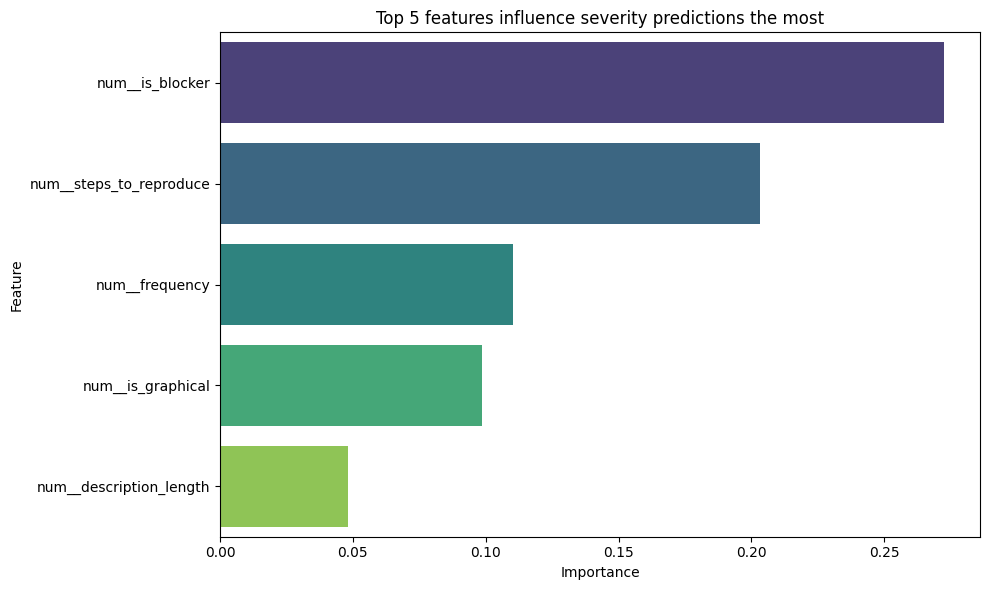

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 5
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(top_n), x='Importance', y='Feature', palette='viridis')
plt.title(f'Top {top_n} features influence severity predictions the most')
plt.tight_layout()
plt.show()
